#### RNN -> LSTM
- 기존 코드에 model 정의 부분만 변경

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

# data loading (자주 등장하는 단어 1만개만 분석에 사용함)
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Train size :", len(X_train))
print("Test size :", len(X_test))

# padding : 리뷰 건마다 텍스트 길이가 다름 -> 300을 기준으로 일치시킨다.
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(X_train, maxlen=300)
test_seq = pad_sequences(X_test, maxlen=300)

print(train_seq.shape, test_seq.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train size : 25000
Test size : 25000
(25000, 300) (25000, 300)


In [2]:
# LSTM model
from tensorflow import keras

model = keras.Sequential()
model.add(keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=300))

# SimpleRNN → LSTM 변경 & 드롭아웃 추가
## 참고. GRU 사용시에는 LSTM -> GRU로 변경
model.add(
    keras.layers.GRU(
        16,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)

model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_imdb_model_LSTM.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# train
history = model.fit(
    train_seq,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(test_seq, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.6233 - loss: 0.6360
Epoch 1: val_loss improved from None to 0.48292, saving model to best_imdb_model_LSTM.keras

Epoch 1: finished saving model to best_imdb_model_LSTM.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.6927 - loss: 0.5757 - val_accuracy: 0.7698 - val_loss: 0.4829
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.8067 - loss: 0.4368
Epoch 2: val_loss improved from 0.48292 to 0.43075, saving model to best_imdb_model_LSTM.keras

Epoch 2: finished saving model to best_imdb_model_LSTM.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.8056 - loss: 0.4330 - val_accuracy: 0.8000 - val_loss: 0.4307
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.8496 - loss: 0.3610
Epoch 3: val_loss improved from 0.43075 to 0.40281, saving model to best_imdb_model_LSTM.keras

Epoch 3: finished saving model to best_imdb_model_LSTM.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 

,accuracy,loss,val_accuracy,val_loss
7,0.93036,0.185539,0.85328,0.351075
8,0.93960,0.165731,0.85388,0.365616
9,0.94248,0.154140,0.85500,0.365279
10,0.95136,0.133660,0.85216,0.386891
11,0.95620,0.121913,0.85380,0.396974


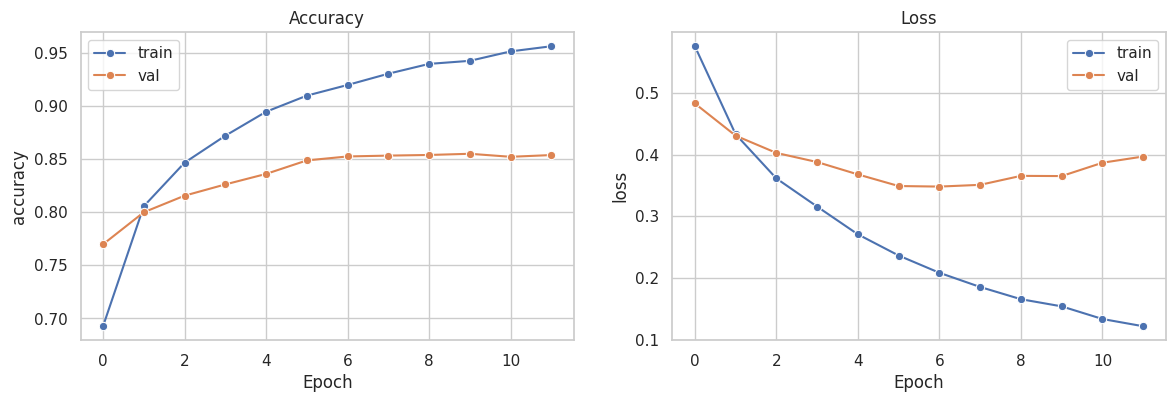

In [4]:
# visuzlaize
df_history = pd.DataFrame(history.history)
display(df_history.tail())

fig, axes = plt.subplots(1,2, figsize=(14,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', label='train', ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', label='val', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel("Epoch")
axes[0].legend()

sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', label='train', ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', label='val', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

In [5]:
# best model loading, test
best_model = keras.models.load_model('best_imdb_model_LSTM.keras')
test_loss, test_acc = best_model.evaluate(test_seq, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 184ms/step - accuracy: 0.8525 - loss: 0.3483
Test accuracy: 0.8524799942970276
Test loss: 0.34825024008750916


#### Performance 비교
- RNN : train accuracy: 0.9710 / val_accuracy: 0.8023 / Test accuracy: 0.8029
- LSTM : train accuracy: 0.9117 / val_accuracy: 0.8177 / Test accuracy: 0.8309
- GRU : train accuracy: 0. / val_accuracy: 0. / Test accuracy: 0.